# K-Nearest Neighbors (KNN) para Detección de Phishing

## Motivación y Decisiones de Implementación

En esta sección se implementa KNN como modelo basado en vecindario para detección de phishing. Este enfoque es apropiado porque:
- **Clasificación por similitud:** Un correo se clasifica según los correos más similares ya vistos. En el espacio TF-IDF, la distancia captura similitud textual real.
- **Adaptabilidad:** No requiere reentrenamiento cada vez que hay nuevos ejemplos de phishing; simplemente se añaden al conjunto de referencia.
- **Optimización necesaria:** KNN es sensible a $k$ y a la métrica de distancia. Se implementa búsqueda de hiperparámetros con Optuna para encontrar la configuración que máximiza generalización en este dataset específico.


In [61]:
from datetime import datetime
from scipy.sparse import load_npz, hstack
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

## Preparación de Datos

### Carga del Dataset

Se cargan los conjuntos de entrenamiento y prueba preprocessados del análisis exploratorio previo:
- **Características TF-IDF:** Vectores de alta dimensionalidad generados por TfidfVectorizer que capturan la importancia de cada término en la clasificación de documentos.
- **Características adicionales:** Features ingenierísticas generadas durante el análisis exploratorio que capturan propiedades lingüísticas y estructurales específicas de correos phishing.


In [62]:
X_train = load_npz('datasets/X_train.npz')
X_test = load_npz('datasets/X_test.npz')
X_extra_train = pd.read_csv('datasets/X_extra_train.csv')
X_extra_test = pd.read_csv('datasets/X_extra_test.csv')

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

### Preprocesamiento y Estandarización

Dado que KNN calcula distancias entre vectores, se requiere estandarización para evitar que características con magnitudes mayores dominen. El pipeline utiliza:
1. **StandardScaler (con_mean=False) para TF-IDF:** Preserva esparcidad de la matriz.
2. **OneHotEncoder para características categóricas:** Convierte `words_count_cat` en binarias.
3. **StandardScaler selectivo para features numéricos:** Estandariza densidad de cláusulas y pronombres a la misma escala.
4. **Concatenación:** Se unen TF-IDF estandarizado + features ingenierísticas preprocesadas con `hstack` para obtener matriz de características combinada.


In [63]:
tfidf_scaler = StandardScaler(with_mean=False)
num_scaler = StandardScaler(with_mean=False)
ohe = OneHotEncoder(drop='first', handle_unknown='ignore')

extra_features_preprocessor = ColumnTransformer(transformers=[
    ('bin', 'passthrough', ['has_link']),
    ('cat', ohe, ['words_count_cat']),
    ('num', num_scaler, ['clause_density', 'pronoun_density']),
], remainder='passthrough')

X_train_scaled = tfidf_scaler.fit_transform(X_train)
X_test_scaled = tfidf_scaler.transform(X_test)

X_train_extra = X_extra_train.drop(['Email Text Raw'], axis=1)
X_test_extra = X_extra_test.drop(['Email Text Raw'], axis=1)

X_train_extra_proc = extra_features_preprocessor.fit_transform(X_train_extra)
X_test_extra_proc = extra_features_preprocessor.transform(X_test_extra)

X_train = hstack([X_train_scaled, X_train_extra_proc])
X_test = hstack([X_test_scaled, X_test_extra_proc])


## Modelo Base: KNN con k=5

Se inicia con $k=5$ como baseline. Este valor es bajo (menos regularización, mayor capacidad de ajuste local) para establecer punto de partida antes de optimización. Se entrena solo sobre `X_train_scaled` (TF-IDF estandarizado) para asegurar que el baseline utiliza la representación más simple disponible.


In [64]:
knn_model = KNeighborsClassifier(n_neighbors=5)

start_train_time = datetime.now()
knn_model.fit(X_train_scaled, y_train)
end_train_time = datetime.now()

train_duration = end_train_time - start_train_time

start_predict_duration = datetime.now()
y_pred = knn_model.predict(X_test_scaled)
end_predict_duration = datetime.now()

predict_duration = end_predict_duration - start_predict_duration

### Evaluación del Modelo Base


Se evalúa el desempeño del modelo mediante una matriz de confusión y métricas de clasificación. Dado el desbalance de clases en el problema (aproximadamente 38% de correos son phishing), se utiliza la exactitud balanceada (promedio de sensibilidad y especificidad) como métrica principal, junto con precisión, recall y F1-score.


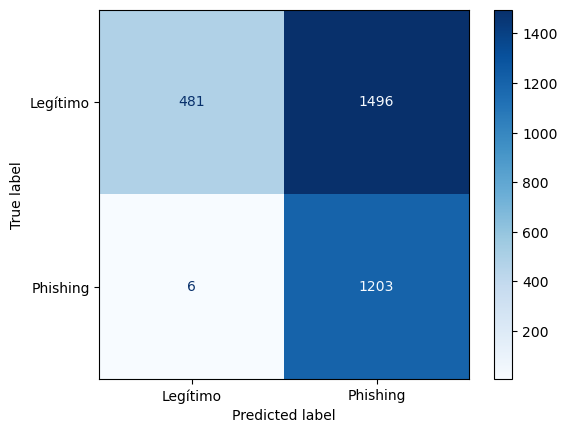

In [65]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [66]:
cm_knn = confusion_matrix(y_test, y_pred)
P = cm_knn[1, :].sum()
N = cm_knn[0, :].sum()
TP = cm_knn[1, 1]
TN = cm_knn[0, 0]

TPR_knn = TP / P
TNR_knn = TN / N
balanced_accuracy_knn = (TPR_knn + TNR_knn) / 2

precision_knn = precision_score(y_test, y_pred, zero_division=0)
recall_knn = recall_score(y_test, y_pred, zero_division=0)
f1_knn = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_knn:.4f}")
print(f"Precisión:               {precision_knn:.4f}")
print(f"Sensibilidad (Recall):   {TPR_knn:.4f}")
print(f"F1-score:                {f1_knn:.4f}")
print(f"Especificidad:           {TNR_knn:.4f}")
print(f"Recuperación (Recall):   {recall_knn:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}")
print(f"Tiempo de predicción:    {predict_duration}")

Exactitud balanceada:    0.6192
Precisión:               0.4457
Sensibilidad (Recall):   0.9950
F1-score:                0.6157
Especificidad:           0.2433
Recuperación (Recall):   0.9950
Tiempo de entrenamiento: 0:00:00.003090
Tiempo de predicción:    0:00:00.369553


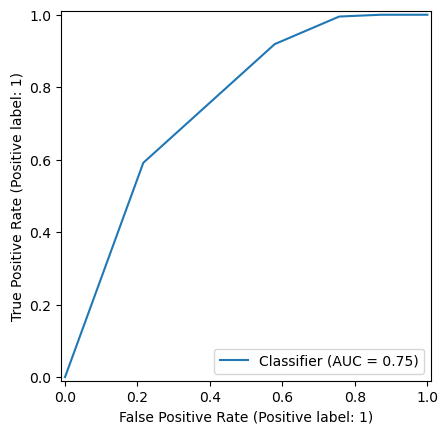

In [67]:
y_scores = knn_model.predict_proba(X_test_scaled)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)


El modelo base con $k=5$ proporciona un punto de partida para evaluar el impacto de la optimización. Aunque ofrece resultados iniciales, existe margen para mejora mediante la sintonización cuidadosa del valor de $k$ y otros hiperparámetros que afectan el cálculo de distancia entre instancias.


## Optimización de Hiperparámetros

Aunque KNN es conceptualmente simple, su desempeño es sensible a varios hiperparámetros clave:

- **n_neighbors (k):** El número de vecinos considerados para la votación. Valores pequeños pueden capturar ruido local, mientras que valores grandes pueden suavizar excesivamente las fronteras de decisión.
- **weights:** La ponderación de los vecinos. "uniform" asigna peso igual a todos los vecinos, mientras que "distance" pondera inversamente por la distancia, dando más importancia a vecinos más cercanos.
- **metric:** La métrica de distancia utilizada. Euclidiana es la más común, pero Manhattan y Coseno pueden ser más apropiadas para ciertos tipos de datos (especialmente Coseno para datos de texto TF-IDF).

Se utiliza Optuna, un framework de optimización bayesiana, para explorar sistemáticamente el espacio de hiperparámetros. El objetivo es maximizar el F1-score en validación cruzada (3-fold), que proporciona una medida equilibrada del desempeño.


In [68]:
def objective(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 50)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    metric = trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"])

    model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric)

    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='f1', n_jobs=-1)
    return score.mean()

def champion_callback(study, frozen_trial):
    winner = study.user_attrs.get("winner", None)

    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value)
            improvement_percent *= 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} "
                f"with {improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: " 
            f"{frozen_trial.value}")

optuna.logging.set_verbosity(optuna.logging.ERROR)

Se ejecutan 100 iteraciones de optimización. Optuna explora combinaciones de hiperparámetros usando una estrategia adaptativa, evaluando cada configuración mediante validación cruzada. Los mejores parámetros encontrados se utilizarán para entrenar el modelo final.


In [69]:
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.HyperbandPruner)
start_train_time_opt = datetime.now()
study.optimize(objective, n_trials=100, callbacks=[champion_callback], n_jobs=-1)
end_train_time_opt = datetime.now()

train_duration_opt = end_train_time_opt - start_train_time_opt

Initial trial 2 achieved value: 0.9018175100354419
Trial 18 achieved value: 0.9022045583977901 with  0.0429% improvement
Trial 26 achieved value: 0.9023899562388563 with  0.0205% improvement
Trial 29 achieved value: 0.9165671320847784 with  1.5468% improvement
Trial 8 achieved value: 0.9167829255250606 with  0.0235% improvement
Trial 35 achieved value: 0.9168001807560863 with  0.0019% improvement


In [70]:
best_params = study.best_params
best_params

{'n_neighbors': 41, 'weights': 'distance', 'metric': 'cosine'}

### Entrenamiento con Parámetros Optimizados

Una vez identificados los mejores hiperparámetros, se entrena un nuevo modelo KNN con la configuración óptima. Los tiempos de entrenamiento y predicción se registran para evaluar la eficiencia computacional del modelo optimizado.


In [71]:
optimized_knn_model = KNeighborsClassifier(**best_params)

start_train_time_opt = datetime.now()
optimized_knn_model.fit(X_train_scaled, y_train)
end_train_time_opt = datetime.now()

train_duration_opt = train_duration_opt + (end_train_time_opt - start_train_time_opt)

start_predict_duration_opt = datetime.now()
y_pred = optimized_knn_model.predict(X_test_scaled)
end_predict_duration_opt = datetime.now()

predict_duration_opt = end_predict_duration_opt - start_predict_duration_opt

### Evaluación del Modelo Optimizado


Se evalúa el modelo optimizado sobre el conjunto de prueba y se comparan los resultados con el modelo base. Se incluye una comparación visual mediante gráfico de barras y curva ROC para facilitar la interpretación del impacto de la optimización.


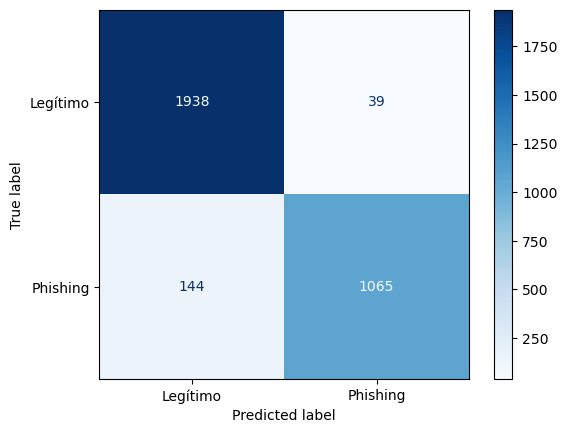

In [72]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [73]:
cm_optimized_knn = confusion_matrix(y_test, y_pred)
P_opt = cm_optimized_knn[1, :].sum()
N_opt = cm_optimized_knn[0, :].sum()
TP_opt = cm_optimized_knn[1, 1]
TN_opt = cm_optimized_knn[0, 0]

TPR_knn_opt = TP_opt / P_opt
TNR_knn_opt = TN_opt / N_opt
balanced_accuracy_knn_opt = (TPR_knn_opt + TNR_knn_opt) / 2

precision_knn_opt = precision_score(y_test, y_pred, zero_division=0)
recall_knn_opt = recall_score(y_test, y_pred, zero_division=0)
f1_knn_opt = f1_score(y_test, y_pred, zero_division=0)

print("                         Antes           Después")
print(f"Exactitud balanceada:    {balanced_accuracy_knn:.4f}          {balanced_accuracy_knn_opt:.4f}")
print(f"Precisión:               {precision_knn:.4f}          {precision_knn_opt:.4f}")
print(f"Sensibilidad (Recall):   {TPR_knn:.4f}          {TPR_knn_opt:.4f}")
print(f"F1-score:                {f1_knn:.4f}          {f1_knn_opt:.4f}")
print(f"Especificidad:           {TNR_knn:.4f}          {TNR_knn_opt:.4f}")
print(f"Recuperación (Recall):   {recall_knn:.4f}          {recall_knn_opt:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}  {train_duration_opt}")
print(f"Tiempo de predicción:    {predict_duration}  {predict_duration_opt}")

                         Antes           Después
Exactitud balanceada:    0.6192          0.9306
Precisión:               0.4457          0.9647
Sensibilidad (Recall):   0.9950          0.8809
F1-score:                0.6157          0.9209
Especificidad:           0.2433          0.9803
Recuperación (Recall):   0.9950          0.8809
Tiempo de entrenamiento: 0:00:00.003090  0:00:52.734191
Tiempo de predicción:    0:00:00.369553  0:00:00.930822


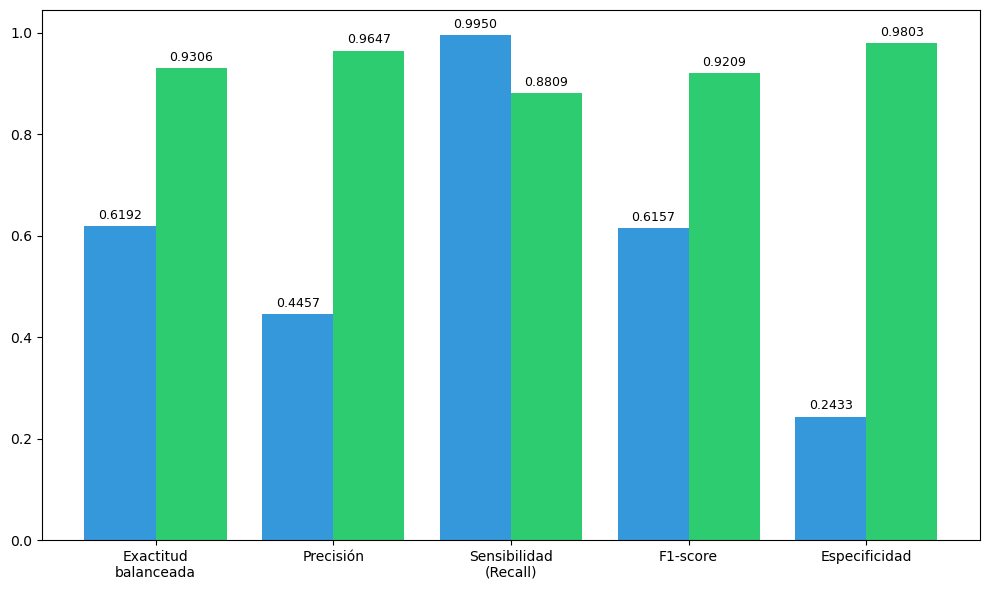

In [74]:
metrics_names = [
    'Exactitud\nbalanceada', 
    'Precisión', 
    'Sensibilidad\n(Recall)', 
    'F1-score', 
    'Especificidad'
]

before_vals = [
    balanced_accuracy_knn, 
    precision_knn, 
    TPR_knn, 
    f1_knn, 
    TNR_knn
]

after_vals = [
    balanced_accuracy_knn_opt, 
    precision_knn_opt, 
    TPR_knn_opt, 
    f1_knn_opt, 
    TNR_knn_opt
]

x = np.arange(5)

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - 0.2, before_vals, 0.4, color='#3498db')
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)
rects2 = ax.bar(x + 0.2, after_vals, 0.4, color='#2ecc71')
for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=10)

plt.tight_layout()
plt.show()


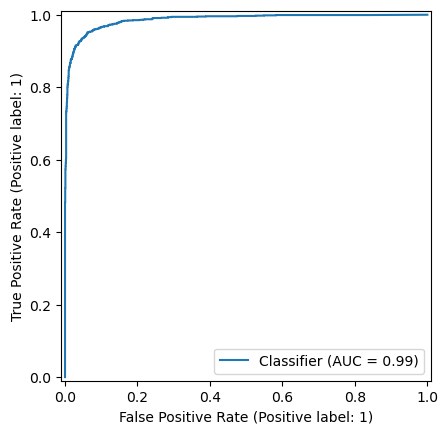

In [75]:
y_scores = optimized_knn_model.predict_proba(X_test_scaled)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)


## Análisis de Resultados y Conclusiones

### Resultados observados

La ejecución realizada en este notebook muestra que el modelo base con $k=5$ tiene un desempeño débil, y que la optimización de hiperparámetros introduce una mejora sustancial en este split.

**Modelo base (k=5):** 0.6192 balanced_accuracy
**Modelo optimizado:** 0.9306 balanced_accuracy

Parámetros óptimos encontrados por Optuna: $k=41$, `weights='distance'`, `metric='cosine'`

| Métrica | Antes (k=5) | Después (optimizado) |
|---|---|---|
| Exactitud balanceada | 0.6192 | 0.9306 |
| Precisión | 0.4457 | 0.9647 |
| Sensibilidad (Recall) | 0.9950 | 0.8809 |
| F1-score | 0.6157 | 0.9209 |
| Especificidad | 0.2433 | 0.9803 |

Esto es relevante porque indica que:
- El modelo base, con pesos uniformes y distancia euclidiana implícita, tenía una sensibilidad casi perfecta pero a costa de una especificidad muy baja (0.2433): estaba prediciendo "phishing" en exceso, generando muchos falsos positivos.
- La optimización corrige fuertemente ese desbalance: la especificidad sube a 0.9803 y la precisión pasa de 0.4457 a 0.9647, a cambio de una pequeña caída en sensibilidad (0.9950 → 0.8809).
- El resultado neto es un clasificador mucho más equilibrado y confiable, reflejado en el salto de balanced accuracy de 0.6192 a 0.9306.

### Interpretación de la optimización

La optimización con Optuna determinó que un vecindario más amplio ($k=41$ en lugar de $k=5$), ponderación por distancia (`weights='distance'`) y métrica coseno (`metric='cosine'`) son mucho más apropiados para este problema que la configuración base. El uso de similitud coseno tiene sentido dado que los vectores TF-IDF son de alta dimensionalidad y dispersos, donde la dirección del vector (y no su magnitud) captura mejor la similitud temática entre correos.

En términos prácticos, esto sugiere que:
- Con pocos vecinos ($k=5$), el modelo era muy sensible a ruido local y a instancias atípicas, lo que inflaba los falsos positivos.
- Ponderar por distancia (`distance`) permite que los vecinos más cercanos influyan más en la predicción, reduciendo el efecto de vecinos lejanos poco relevantes.
- La métrica coseno resulta más adecuada que la euclidiana para el espacio TF-IDF, ya que normaliza el efecto de la longitud del documento.

### Características utilizadas

KNN utiliza **TF-IDF + features ingenierísticas** (`has_link`, `words_count_cat`, `clause_density`, `pronoun_density`), lo que le permite combinar similitud textual con señales estructurales del correo. Esto es útil en la detección de phishing porque una parte importante del problema no depende solo de palabras aisladas, sino también de la forma del mensaje y de ciertos indicadores de estructura.

### Observaciones técnicas

1. **Predicción sobre X_test_scaled:** El uso de la misma representación usada durante entrenamiento es fundamental para evitar errores de dimensionalidad y sesgos en la distancia.
2. **Costo computacional:** El KNN optimizado requiere considerablemente más tiempo de entrenamiento que el baseline (≈52.7s vs ≈0.003s), y también un poco más de tiempo de predicción (≈0.93s vs ≈0.37s), debido al mayor $k$ y al cálculo de la búsqueda de vecinos ponderada.
3. **Conclusión práctica:** La optimización de hiperparámetros resultó ser clave para este modelo: transformó un clasificador desbalanceado (alta sensibilidad, baja especificidad) en uno robusto y equilibrado, a un costo computacional adicional razonable dado el tamaño del dataset.

---